In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [2]:
users = pd.read_csv("../data/users2.csv")
events = pd.read_csv("../data/events_base2.csv")
resources = pd.read_csv("../data/resources2.csv")
sessions = pd.read_csv("../data/sessions2.csv")

### Merging all 4 files into a single df

In [3]:
df = sessions.merge(events, on=["session_id", 'user_id'], how = 'left')
df = df.merge(users, on =['user_id'], how = 'left')
df = df.merge(resources, on = ['resource_id'], how = 'left')

### Feature Engineering per event

In [7]:
df

,session_id,user_id,session_start,session_end,device_type,location,login_method,mfa_used,failed_login_attempts,event_id,timestamp,event_type,action,resource_id,data_volume_mb,access_success,privilege_used,admin_command_type,role,department,privilege_level,tenure_months,typical_login_hour,login_hour_std,employment_status,remote_worker,behavior_variability_score,resource_type,owner_department,sensitivity_score,required_privilege_level,resource_size_mb,access_scope
0,S00001,U000,2025-01-01 11:21:00,2025-01-01 13:14:00,laptop,India,password+token,True,0,E000001,2025-01-01 11:26:00,file_access,read,R002,0.00,False,1.0,NaN,user,Finance,1,32,9.85,1.04,active,False,0.36,sensitive,Finance,0.55,2.0,132.53,cross_department
1,S00001,U000,2025-01-01 11:21:00,2025-01-01 13:14:00,laptop,India,password+token,True,0,E000002,2025-01-01 11:32:00,file_access,read,R004,2.74,True,1.0,NaN,user,Finance,1,32,9.85,1.04,active,False,0.36,public,Finance,0.21,1.0,39.47,cross_department
2,S00001,U000,2025-01-01 11:21:00,2025-01-01 13:14:00,laptop,India,password+token,True,0,E000003,2025-01-01 11:48:00,file_access,read,R002,0.00,False,1.0,NaN,user,Finance,1,32,9.85,1.04,active,False,0.36,sensitive,Finance,0.55,2.0,132.53,cross_department
3,S00001,U000,2025-01-01 11:21:00,2025-01-01 13:14:00,laptop,India,password+token,True,0,E000004,2025-01-01 12:06:00,file_access,read,R003,15.55,True,1.0,NaN,user,Finance,1,32,9.85,1.04,active,False,0.36,sensitive,Finance,0.46,1.0,325.33,department_only
4,S00001,U000,2025-01-01 11:21:00,2025-01-01 13:14:00,laptop,India,password+token,True,0,E000005,2025-01-01 12:09:00,file_access,read,R002,0.00,False,1.0,NaN,user,Finance,1,32,9.85,1.04,active,False,0.36,sensitive,Finance,0.55,2.0,132.53,cross_department
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8977,S01006,U019,2025-02-14 13:44:00,2025-02-14 16:04:00,laptop,India,password,False,2,E008976,2025-02-14 14:28:00,file_access,read,R030,0.24,True,1.0,NaN,user,HR,1,42,10.59,1.35,active,False,0.63,public,Sales,0.25,1.0,12.10,global
8978,S01006,U019,2025-02-14 13:44:00,2025-02-14 16:04:00,laptop,India,password,False,2,E008977,2025-02-14 14:42:00,file_export,export,R039,0.00,False,1.0,NaN,user,HR,1,42,10.59,1.35,active,False,0.63,sensitive,HR,0.67,2.0,92.15,cross_department
8979,S01006,U019,2025-02-14 13:44:00,2025-02-14 16:04:00,laptop,India,password,False,2,E008978,2025-02-14 15:26:00,file_access,read,R004,2.73,True,1.0,NaN,user,HR,1,42,10.59,1.35,active,False,0.63,public,Finance,0.21,1.0,39.47,cross_department
8980,S01006,U019,2025-02-14 13:44:00,2025-02-14 16:04:00,laptop,India,password,False,2,E008979,2025-02-14 15:40:00,file_access,read,R023,0.00,False,1.0,NaN,user,HR,1,42,10.59,1.35,active,False,0.63,sensitive,Security,0.59,2.0,283.46,cross_department


In [8]:
df["cross_department_access"] = (
    df["department"] != df["owner_department"]
).astype(int)

In [9]:
df["global_access"] = (
    df["access_scope"] == "global"
)

In [10]:
df["scope_violation"] = (
    (df["cross_department_access"] == 1) & (df["access_scope"] == "department_only")
)

In [11]:
df["sensitive_access"] = (
    df["resource_type"] == "sensitive"
).astype(int)

In [12]:
df['admin_only_access'] = (
    df["resource_type"] == "admin_only"
).astype(int)

In [15]:
df["invalid_access"] = (
    df["access_success"] == False
).astype(int)

### Grouping the data on each session

In [19]:
sessions_df = df.groupby("session_id").agg({
    "event_id": "count",
    "data_volume_mb": "sum",
    "invalid_access": "sum",
    "cross_department_access": "sum",
    "global_access": "sum",
    "scope_violation": "sum",
    "sensitive_access": "sum",
    "admin_only_access": "sum",
    "resource_id": "nunique",
    "sensitivity_score": "mean"
}).reset_index()

In [20]:
sessions_df = sessions_df.rename(columns={
    "event_id": "total_events",
    "data_volume_mb": "total_data_volume",
    "invalid_access": "failed_attempts",
    "cross_department_access": "cross_dept_count",
    "global_access": "global_access_count",
    "scope_violation": "scope_violation_count",
    "sensitive_access": "sensitive_resource_count",
    "admin_only_access": "admin_only_resource_count",
    "resource_id": "unique_resources",
    "sensitivity_score": "avg_sensitivity"
})

In [21]:
sessions_df = sessions_df.merge(
    sessions,
    on=["session_id"],
    how="left"
)

In [23]:
sessions_df = sessions_df.merge(
    users[[
        "user_id",
        "tenure_months",
        "role",
        "privilege_level",
        "typical_login_hour",
        "login_hour_std",
        "employment_status",
        "remote_worker",
        "behavior_variability_score"
    ]],
    on="user_id",
    how="left"
)

In [24]:
sessions_df

,session_id,total_events,total_data_volume,failed_attempts,cross_dept_count,global_access_count,scope_violation_count,sensitive_resource_count,admin_only_resource_count,unique_resources,avg_sensitivity,user_id,session_start,session_end,device_type,location,login_method,mfa_used,failed_login_attempts,tenure_months,role,privilege_level,typical_login_hour,login_hour_std,employment_status,remote_worker,behavior_variability_score
0,S00001,8,20.17,5,1,0,0,6,0,5,0.460000,U000,2025-01-01 11:21:00,2025-01-01 13:14:00,laptop,India,password+token,True,0,32,user,1,9.85,1.04,active,False,0.36
1,S00002,9,82.15,2,1,1,0,5,0,5,0.367778,U000,2025-01-01 14:28:00,2025-01-01 16:06:00,laptop,India,password+token,True,0,32,user,1,9.85,1.04,active,False,0.36
2,S00003,3,0.73,2,0,0,0,2,0,2,0.436667,U000,2025-01-01 17:57:00,2025-01-01 18:56:00,vpn,India,password+token,True,0,32,user,1,9.85,1.04,active,False,0.36
3,S00004,8,13.65,5,1,1,0,6,0,6,0.461250,U000,2025-01-02 10:47:00,2025-01-02 12:49:00,workstation,India,password,True,2,32,user,1,9.85,1.04,active,False,0.36
4,S00005,5,25.97,1,0,0,0,2,0,4,0.326000,U000,2025-01-03 00:23:00,2025-01-03 02:03:00,laptop,Germany,password+token,False,1,32,user,1,9.85,1.04,active,False,0.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,S01002,9,0.00,9,1,1,0,9,0,5,0.586667,U019,2025-02-12 09:05:00,2025-02-12 11:41:00,workstation,Singapore,password+token,True,3,42,user,1,10.59,1.35,active,False,0.63
1002,S01003,5,0.00,5,0,0,0,5,0,4,0.568000,U019,2025-02-13 12:20:00,2025-02-13 14:07:00,laptop,India,password,False,2,42,user,1,10.59,1.35,active,False,0.63
1003,S01004,6,4.11,3,3,1,0,3,0,6,0.418333,U019,2025-02-13 15:03:00,2025-02-13 17:14:00,laptop,India,password,True,1,42,user,1,10.59,1.35,active,False,0.63
1004,S01005,6,2.35,5,1,1,0,5,0,6,0.533333,U019,2025-02-14 10:01:00,2025-02-14 12:34:00,workstation,India,password+token,True,1,42,user,1,10.59,1.35,active,False,0.63


### Adding event types and session duration

In [25]:
sessions_df["session_duration"] = (
    pd.to_datetime(sessions_df["session_end"]) -
    pd.to_datetime(sessions_df["session_start"])
).dt.total_seconds() / 60

In [27]:
event_type_counts = pd.crosstab(df["session_id"], df["event_type"])

In [145]:
grouped_df = grouped_df.merge(
    event_type_counts,
    on="session_id",
    how="left"
)

### Calculating the login hour deviation

In [146]:
grouped_df["login_hour"] = pd.to_datetime(
    grouped_df["session_start"]
).dt.hour

In [147]:
grouped_df["login_zscore"] = (
    grouped_df["login_hour"] - grouped_df["typical_login_hour"]
) / grouped_df["login_hour_std"]

grouped_df["abs_login_z"] = abs(grouped_df["login_zscore"])

### Dropping redudant columns which are unique and date times

In [148]:
grouped_df = grouped_df.drop(columns=["session_start", "session_end"])

### Storing event ratios instead of raw counts

In [149]:
grouped_df["failed_ratio"] = (
    grouped_df["failed_attempts"] / grouped_df["total_events"]
)

In [150]:
grouped_df["admin_ratio"] = (
    grouped_df["admin_action"] / grouped_df["total_events"]
)

In [151]:
grouped_df["sensitive_ratio"] = (
    grouped_df["sensitive_resource_count"] / grouped_df["total_events"]
)

In [152]:
grouped_df["admin_only_ratio"] = (
    grouped_df["admin_only_resource_count"] / grouped_df["total_events"]
)

In [153]:
grouped_df["cross_dept_ratio"] = (
    grouped_df["cross_dept_count"] / grouped_df["total_events"]
)

In [154]:
grouped_df["resource_density"] = (
    grouped_df["unique_resources"] / grouped_df["total_events"]
)

In [155]:
grouped_df["api_ratio"] = (
    grouped_df["api_call"] / grouped_df["total_events"]
)

KeyError: 'api_call'

In [ ]:
grouped_df["file_ratio"] = (
    grouped_df["file_access"] / grouped_df["total_events"]
)

In [ ]:
grouped_df["events_per_minute"] = (
    grouped_df["total_events"] /
    grouped_df["session_duration"]
)

In [ ]:
grouped_df["avg_data_per_event"] = (
    grouped_df["total_data_volume"] / grouped_df["total_events"]
)

In [ ]:
grouped_df = grouped_df.drop(columns=["cross_dept_count", "sensitive_resource_count","admin_only_resource_count", "admin_action", 'failed_attempts'])

### Dropping columns whose insights have been feature engineered

In [ ]:
grouped_df = grouped_df.drop(columns=["typical_login_hour", "login_hour_std", "api_call", "file_access", "admin_misuse_count", "unique_resources","login_zscore"])

In [ ]:
grouped_df.head()

,session_id,total_events,total_data_volume,avg_sensitivity,user_id,device_type,location,login_method,mfa_used,tenure_months,role,privilege_level,session_duration,login_hour,abs_login_z,failed_ratio,admin_ratio,sensitive_ratio,admin_only_ratio,cross_dept_ratio,resource_density,api_ratio,file_ratio,events_per_minute,avg_data_per_event
0,S00001,11,252,0.629091,U000,laptop,India,password,True,32,user,1,112.0,9,0.817308,0.000000,0.0,0.636364,0.0,1.000000,0.545455,0.181818,0.818182,0.098214,22.909091
1,S00002,5,29,0.502000,U000,vpn,India,password,False,32,user,1,53.0,8,1.778846,0.200000,0.0,0.400000,0.0,1.000000,0.800000,0.000000,1.000000,0.094340,5.800000
2,S00003,7,42,0.505714,U000,laptop,India,password,False,32,user,1,50.0,8,1.778846,0.142857,0.0,0.571429,0.0,0.714286,1.000000,0.571429,0.428571,0.140000,6.000000
3,S00004,6,77,0.486667,U000,vpn,India,password,True,32,user,1,51.0,11,1.105769,0.000000,0.0,0.500000,0.0,0.500000,0.833333,0.333333,0.666667,0.117647,12.833333
4,S00005,7,63,0.485714,U000,vpn,India,password+token,True,32,user,1,71.0,9,0.817308,0.000000,0.0,0.428571,0.0,0.428571,0.714286,0.428571,0.571429,0.098592,9.000000


In [ ]:
grouped_df.select_dtypes(include=['float64', 'int64']).corr()

,total_events,total_data_volume,avg_sensitivity,tenure_months,privilege_level,session_duration,abs_login_z,failed_ratio,admin_ratio,sensitive_ratio,admin_only_ratio,cross_dept_ratio,resource_density,api_ratio,file_ratio,events_per_minute,avg_data_per_event
total_events,1.000000,0.440414,-0.131223,0.047908,0.151020,0.285011,0.027942,-0.179337,0.066076,-0.072812,-0.056461,0.058385,-0.455034,-0.015355,0.003592,0.475534,0.031445
total_data_volume,0.440414,1.000000,-0.122505,0.047471,0.087116,0.255815,0.068556,-0.212527,0.072493,-0.091962,-0.042793,0.044392,-0.130016,-0.201202,0.189175,0.093376,0.831602
avg_sensitivity,-0.131223,-0.122505,1.000000,0.093073,-0.043912,-0.201562,0.022607,0.160824,-0.060403,0.566195,0.222014,0.043183,-0.094994,0.074611,-0.064147,0.060309,-0.052600
tenure_months,0.047908,0.047471,0.093073,1.000000,0.544663,-0.012518,0.155238,-0.038345,-0.158915,0.076037,-0.153280,0.203075,0.086757,0.066233,-0.038082,0.007094,-0.005113
privilege_level,0.151020,0.087116,-0.043912,0.544663,1.000000,0.138711,-0.014651,-0.025598,-0.109764,0.069063,-0.256652,0.410943,-0.003092,0.057547,-0.038159,-0.034915,0.012596
session_duration,0.285011,0.255815,-0.201562,-0.012518,0.138711,1.000000,-0.001181,-0.189849,0.151248,-0.170751,-0.046408,0.013799,-0.001686,-0.052327,0.025483,-0.599299,0.137755
abs_login_z,0.027942,0.068556,0.022607,0.155238,-0.014651,-0.001181,1.000000,-0.051360,0.023484,-0.044421,0.055559,0.050272,0.028882,0.000151,-0.004359,-0.005813,0.063996
failed_ratio,-0.179337,-0.212527,0.160824,-0.038345,-0.025598,-0.189849,-0.051360,1.000000,-0.080110,0.176605,-0.025520,0.102952,-0.082677,-0.023283,0.037744,-0.004477,-0.204554
admin_ratio,0.066076,0.072493,-0.060403,-0.158915,-0.109764,0.151248,0.023484,-0.080110,1.000000,-0.027770,-0.075526,-0.092442,0.076363,-0.115692,-0.062889,-0.042411,0.035513
sensitive_ratio,-0.072812,-0.091962,0.566195,0.076037,0.069063,-0.170751,-0.044421,0.176605,-0.027770,1.000000,-0.423209,0.134255,-0.040010,-0.067042,0.072336,0.073629,-0.073595


## Visualizing Trends in the data and defining normal behaviour

In [ ]:
fig = px.histogram(
    grouped_df,
    x="session_duration",
    nbins=40,
    title="Session Duration Distribution",
    hover_data=["session_id", "role"]
)

fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.histogram(
    grouped_df,
    x="abs_login_z",
    nbins=40,
    title="Login Deviation (Z-Score) Distribution",
    hover_data=["session_id", "role"]
)

fig.show()

In [ ]:
fig = px.histogram(
    grouped_df,
    x="failed_ratio",
    nbins=40,
    title="Failed Access Ratio Distribution",
    hover_data=["session_id", "role"]
)

fig.show()

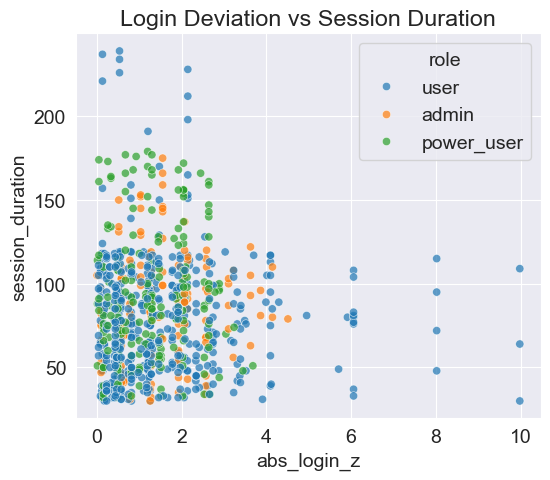

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=grouped_df,
    x="abs_login_z",
    y="session_duration",
    hue="role",
    alpha=0.7
)
plt.title("Login Deviation vs Session Duration")
plt.show()

In [ ]:
fig = px.scatter(
    grouped_df,
    x="abs_login_z",
    y="admin_ratio",
    color="role",
    hover_data=["session_id", "total_events"],
    title="Login Deviation vs Admin Usage"
)

fig.show()

In [ ]:
fig = px.scatter(
    grouped_df,
    x="session_duration",
    y="total_data_volume",
    color="role",
    hover_data=["session_id"],
    title="Session Duration vs Data Volume"
)

fig.show()

In [ ]:
fig = px.scatter(
    grouped_df,
    x="events_per_minute",
    y="avg_data_per_event",
    color="role",
    hover_data=["session_id"],
    title="Activity Burstiness vs Data Intensity"
)

fig.show()

In [ ]:
fig = px.box(
    grouped_df,
    x="privilege_level",
    y="total_events",
    color="privilege_level",
    hover_data=["session_id"],
    title="Activity Level by Privilege Level"
)

fig.show()

In [ ]:
corr = grouped_df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=False,
    color_continuous_scale="RdBu",
    title="Feature Correlation Heatmap"
)

fig.show()

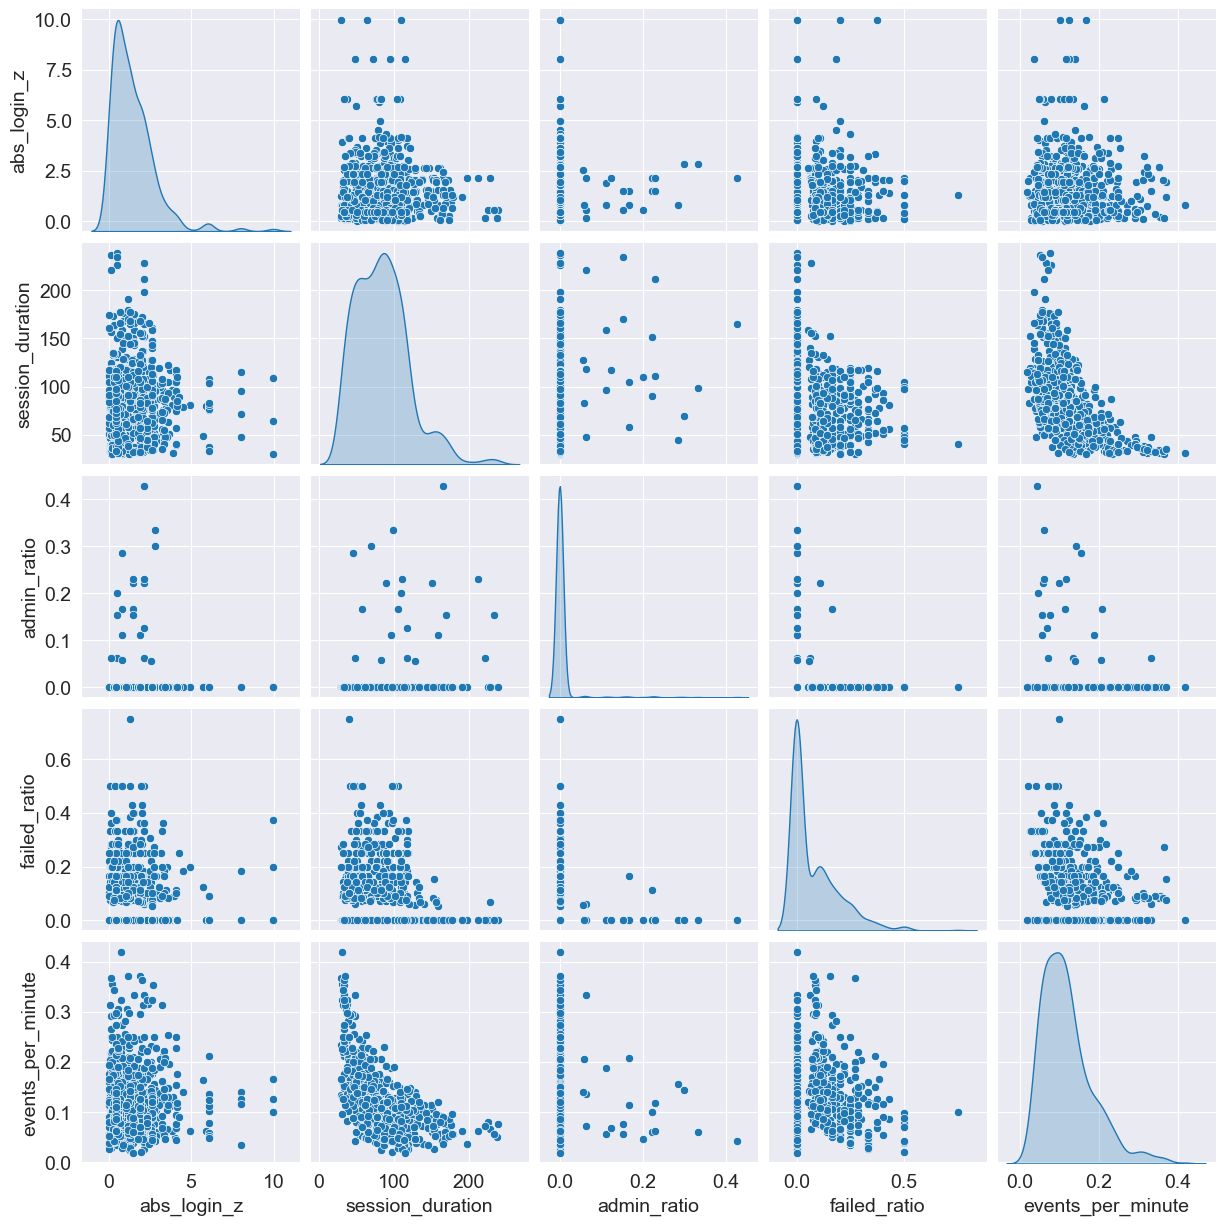

In [ ]:
sns.pairplot(
    grouped_df[[
        "abs_login_z",
        "session_duration",
        "admin_ratio",
        "failed_ratio",
        "events_per_minute"
    ]],
    diag_kind="kde"
)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_df = grouped_df.select_dtypes(include="number")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

grouped_df["PC1"] = X_pca[:,0]
grouped_df["PC2"] = X_pca[:,1]

fig = px.scatter(
    grouped_df,
    x="PC1",
    y="PC2",
    color="role",
    hover_data=[
        "session_id",
        "abs_login_z",
        "admin_ratio",
        "failed_ratio"
    ],
    title="PCA Projection of Sessions"
)

fig.show()